<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Force012.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 512
e_folds = 10000
beta_drift = 1/48  # Scalar–echo drift coupling


In [2]:
def generate_scalar_gradient(grid_size):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    return np.sin(X) + 0.5 * np.sin(Y)


In [3]:
def generate_echo_field(grid_size):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    return np.sin(X + Y)


In [4]:
def echo_scalar_drift(echo, scalar, beta=1/48):
    grad_scalar_x, grad_scalar_y = np.gradient(scalar)
    grad_echo_x, grad_echo_y = np.gradient(echo)

    theta_scalar = np.arctan2(grad_scalar_y, grad_scalar_x)
    theta_echo = np.arctan2(grad_echo_y, grad_echo_x)
    phase_diff = theta_echo - theta_scalar

    drift = -beta * np.sin(phase_diff)
    echo += drift
    return echo


In [5]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [6]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]

def drift_asymmetry(field):
    left = field[:, :grid_size//2]
    right = field[:, grid_size//2:]
    return np.mean(right**2) - np.mean(left**2)


Echo fidelity: 0.9696
Drift asymmetry: -0.000102


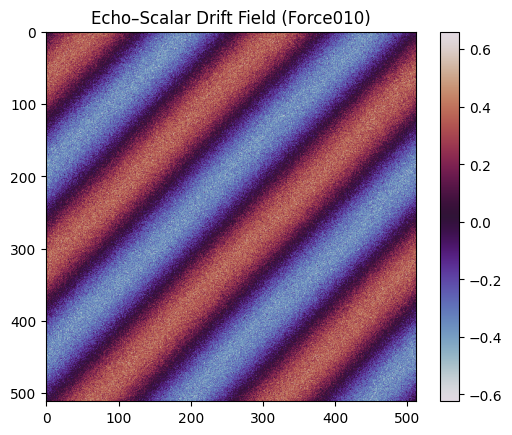

In [7]:
scalar = generate_scalar_gradient(grid_size)
echo = generate_echo_field(grid_size)
echo_c = echo_scalar_drift(echo, scalar, beta_drift)
echo_e = evolve_field(echo_c, e_folds)

fidelity = memory_fidelity(echo_c, echo_e)
asymmetry = drift_asymmetry(echo_e)

print(f"Echo fidelity: {fidelity:.4f}")
print(f"Drift asymmetry: {asymmetry:.6f}")

plt.imshow(echo_e, cmap='twilight')
plt.title("Echo–Scalar Drift Field (Force010)")
plt.colorbar()
plt.show()
